In [37]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [38]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


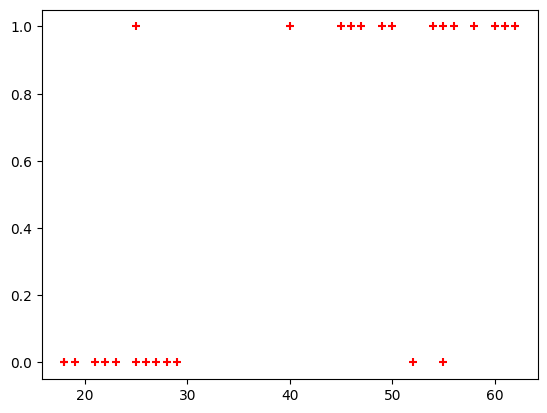

In [39]:
plt.scatter(df.age, df.bought_insurance, marker = "+", color = "red")

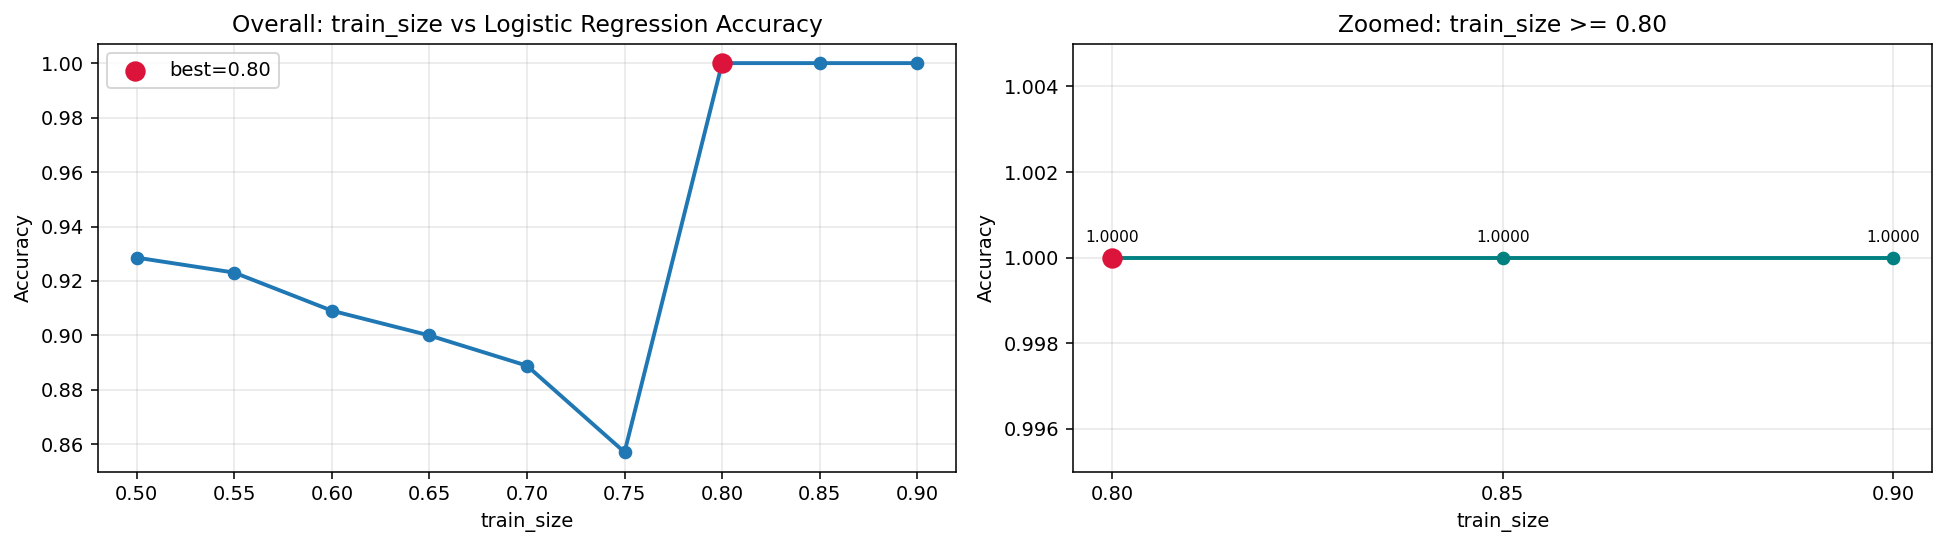

Selected best train_size: 0.80
Best accuracy score: 1.0000


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

X = df[["age"]]
y = df.bought_insurance

train_sizes = np.arange(0.5, 0.95, 0.05)
scores = []

for ts in train_sizes:
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X, y, train_size=ts, random_state=42
    )
    model_tmp = LogisticRegression(max_iter=1000)
    model_tmp.fit(X_train_tmp, y_train_tmp)
    scores.append(model_tmp.score(X_test_tmp, y_test_tmp))

best_idx = int(np.argmax(scores))
best_train_size = float(train_sizes[best_idx])
score_arr = np.array(scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=140)

# Overall trend
axes[0].plot(train_sizes, score_arr, marker="o", linewidth=2)
axes[0].scatter(best_train_size, score_arr[best_idx], color="crimson", s=90, zorder=3, label=f"best={best_train_size:.2f}")
axes[0].set_title("Overall: train_size vs Logistic Regression Accuracy")
axes[0].set_xlabel("train_size")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(train_sizes)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Zoom in to inspect splits after 0.80
mask = train_sizes >= 0.80
zoom_x = train_sizes[mask]
zoom_y = score_arr[mask]
zoom_margin = max((zoom_y.max() - zoom_y.min()) * 0.25, 0.005)

axes[1].plot(zoom_x, zoom_y, marker="o", linewidth=2, color="teal")
if best_train_size >= 0.80:
    axes[1].scatter(best_train_size, score_arr[best_idx], color="crimson", s=90, zorder=3)
axes[1].set_title("Zoomed: train_size >= 0.80")
axes[1].set_xlabel("train_size")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(zoom_x)
axes[1].set_ylim(zoom_y.min() - zoom_margin, zoom_y.max() + zoom_margin)
axes[1].grid(True, alpha=0.3)

for x_val, y_val in zip(zoom_x, zoom_y):
    axes[1].annotate(
        f"{y_val:.4f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print(f"Selected best train_size: {best_train_size:.2f}")
print(f"Best accuracy score: {score_arr[best_idx]:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=best_train_size, random_state=42
)


In [41]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [42]:
X_train

,age
16,25
17,58
12,27
24,50
1,25
4,46
5,56
2,47
15,55
22,40


In [43]:
X_test

,age
8,62
13,29
9,61
21,26
0,22
11,28


In [44]:
y_train 

16    1
17    1
12    0
24    1
1     0
4     1
5     1
2     1
15    1
22    1
3     0
25    1
23    1
18    0
26    0
20    0
7     1
10    0
14    1
19    0
6     0
Name: bought_insurance, dtype: int64

In [45]:
y_test

8     1
13    0
9     1
21    0
0     0
11    0
Name: bought_insurance, dtype: int64

In [46]:
y_predicted = model.predict(X_test)
model.predict_proba(X_test)

array([[0.05428672, 0.94571328],
       [0.7055532 , 0.2944468 ],
       [0.06039333, 0.93960667],
       [0.77084966, 0.22915034],
       [0.84096469, 0.15903531],
       [0.72848723, 0.27151277]])

In [47]:
y_predicted

array([1, 0, 1, 0, 0, 0])

In [48]:
model.coef_ # indicates the slope of the line or value of m in y = mx + c

array([[0.11307708]])

In [49]:
model.intercept_ # indicates the value of c in y = mx + c

array([-4.15311919])

In [50]:
import math
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [51]:
def prediction_function(age):
    linear_combination = model.coef_[0][0] * age + model.intercept_[0]
    probability = sigmoid(linear_combination)
    return probability

In [52]:
age = 35
probability = prediction_function(age)
probability
if probability < 0.5:
    print(f"'{probability:.3f} is less than 0.5 which means person with {age} age will not buy insurance'")
else:
    print(f"'{probability:.3f} is greater than or equal to 0.5 which means person with {age} age will buy insurance'")

'0.451 is less than 0.5 which means person with 35 age will not buy insurance'


In [53]:
age = 43
probability = prediction_function(age)
probability
if probability < 0.5:
    print(f"'{probability:.3f} is less than 0.5 which means person with {age} age will not buy insurance'")
else:
    print(f"'{probability:.3f} is greater than or equal to 0.5 which means person with {age} age will buy insurance'")

'0.670 is greater than or equal to 0.5 which means person with 43 age will buy insurance'
